# Lab: Visualizing Text Data

Online reviews contain information that cannot be summarized directly until we decide what evidence to extract from the text. In this lab, you will compare historical high- and low-rated visitor reviews of Universal Studios Florida.

Ratings tell us whether visitors evaluated their experiences favorably. The review text can help us investigate what visitors chose to discuss, while review length gives us a simple quantitative feature calculated from text.

## Learning goals

By the end of this lab, you should be able to:

- prepare review text for analysis;
- convert text into word-frequency and review-length features;
- create and interpret word clouds, frequency bar charts, and a box plot;
- compare text-derived evidence across groups; and
- explain important limits of review and word-frequency data.

## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding and checking every submitted response. Do not submit an AI response that you cannot explain.

## Dataset

The dataset is a fixed random sample of 3,000 English-language reviews of Universal Studios Florida. It was prepared from the CC0 [*Reviews of Universal Studios* dataset published on Kaggle](https://www.kaggle.com/datasets/dwiknrd/reviewuniversalstudio). The source contains more than 50,000 reviews of the Florida, Japan, and Singapore parks that were posted on Tripadvisor. For this dataset, the Florida reviews were selected, text encoding was repaired where possible, duplicate and blank reviews were removed, reviewer names were omitted, and a fixed random sample was drawn while retaining the source rating distribution.

The dataset contains four features and no missing values. Its reviews extend from February 2004 through May 2021, so they describe historical visitor experiences rather than current park conditions. The sample retains the unequal rating distribution found in the source data: a much larger number of reviews have ratings of four or five stars than ratings of one or two stars. It should not be treated as a representative sample of all visitors.

# Step 1: Question

> **How did high- and low-rated Universal Studios Florida reviews differ in their commonly used words and review lengths?**

For this analysis:

- **Low-rated reviews** have ratings of one or two stars.
- **High-rated reviews** have ratings of four or five stars.
- Three-star reviews are treated as neutral and are not included in the comparison.

**What topics or words do you predict will be especially common in low-rated reviews?**

Your answer: I predict low-rated reviews will especially mention long wait times or lines, crowds, ticket or Express Pass prices, and disappointment about specific rides being closed or broken down. Words like "wait," "line," "expensive," "crowded," and "money" seem likely.


**Do you predict that low- or high-rated reviews will generally be longer?**

Your answer: I predict low-rated reviews will generally be longer, because dissatisfied visitors often feel they need to explain and justify multiple specific problems, while a satisfied visitor can express a positive experience more briefly.


# Step 2: Data

## Install WordCloud if needed

`wordcloud` is not included automatically in every Python environment. If you have not installed it in the current environment, run the next cell before importing the libraries. You normally need to install it only once for an environment.

If it is already installed, the command will confirm that the requirement is satisfied.

In [ ]:
%pip install wordcloud

## 1. Import the libraries

The specialized imports for regular expressions, word counts, stopwords, and word clouds are provided. Complete the following code cell by importing Pandas, Matplotlib's `pyplot`, and Seaborn using their conventional aliases.

In [2]:
import re
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from wordcloud import WordCloud

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Read the data

Read `data/universal_orlando_reviews_sample.csv` into a DataFrame named `reviews`. Use `parse_dates=["review_date"]`.

In [3]:
reviews = pd.read_csv(
    "data/universal_orlando_reviews_sample.csv",
    parse_dates=["review_date"]
)


## 3. Preview and inspect the DataFrame

Display the first five rows, last five rows, stored data types, and missing-value counts.

In [4]:
display(reviews.head())
display(reviews.tail())
reviews.info()
reviews.isnull().sum()


,review_id,rating,review_text,review_date
0,1,5.0,"If you visit Orlando, you have to take two day...",2004-02-17
1,2,5.0,"My family of 5 ( 2 adults, 3 kids(17,17,+3) ha...",2004-07-06
2,3,1.0,Went to universal this september. What a waste...,2004-10-25
3,4,5.0,I think these parks (Universal Studios and Isl...,2005-01-03
4,5,1.0,"3 hours to get on a ride, $5 icees and $7 for ...",2005-03-31


,review_id,rating,review_text,review_date
2995,2996,1.0,TLDR; They don’t observe or enforce Covid safe...,2021-04-28
2996,2997,1.0,I've been waiting multiple DAYS on the phone t...,2021-05-04
2997,2998,1.0,✅ $850💵 + ⏰ hours of high heat 91 degrees🔥 & 😷...,2021-05-04
2998,2999,3.0,My husband and I visited Universal a couple ye...,2021-05-06
2999,3000,5.0,Harry Potter world was especially awesome and ...,2021-05-15


<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   review_id    3000 non-null   int64         
 1   rating       3000 non-null   float64       
 2   review_text  3000 non-null   str           
 3   review_date  3000 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 93.9 KB


review_id      0
rating         0
review_text    0
review_date    0
dtype: int64

### Data dictionary

| Feature | Meaning |
| --- | --- |
| `review_id` | Course-dataset identifier for a review |
| `rating` | Visitor rating from one to five stars |
| `review_text` | Written visitor review |
| `review_date` | Calendar date associated with the review |

Complete the table using the data dictionary, `.info()`, and `.isnull().sum()`.

| Feature | Feature type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `review_id` | Categorical (identifier) | int64 | 0 |
| `rating` | Quantitative (discrete, 1-5) | float64 | 0 |
| `review_text` | Text | str (object) | 0 |
| `review_date` | Temporal | datetime64[us] | 0 |


**What does one row represent?**

Your answer: One row represents a single visitor's written review of Universal Studios Florida, including the star rating they gave and the date associated with that review.


**What population can this dataset help us understand?**

Your answer: This dataset can help us understand visitors who chose to write an English-language Tripadvisor review of Universal Studios Florida between February 2004 and May 2021. It does not represent all park visitors, since only a self-selected group of visitors write online reviews, and it describes historical rather than current visitor experiences.


# Step 3: Operation

## 4. Create rating groups

Use `pd.cut()` to create `rating_group` from `rating` with:

- `bins=[0, 2, 3, 5]`; and
- `labels=["Low (1–2)", "Neutral (3)", "High (4–5)"]`.

Then display the frequency of each group in rating order. The intervals created by these bins place ratings greater than 0 through 2 in Low, greater than 2 through 3 in Neutral, and greater than 3 through 5 in High.

In [5]:
reviews["rating_group"] = pd.cut(
    reviews["rating"],
    bins=[0, 2, 3, 5],
    labels=["Low (1–2)", "Neutral (3)", "High (4–5)"]
)

reviews["rating_group"].value_counts().reindex(
    ["Low (1–2)", "Neutral (3)", "High (4–5)"]
)


rating_group
Low (1–2)       273
Neutral (3)     278
High (4–5)     2449
Name: count, dtype: int64

## 5. Select the comparison groups

Create `comparison` containing reviews whose `rating_group` is not `Neutral (3)`. Use `.copy()` because you will add calculated features to this new DataFrame.

In [6]:
comparison = reviews[reviews["rating_group"] != "Neutral (3)"].copy()


**Why are three-star reviews excluded from this particular comparison?**

Your answer: Three-star reviews are treated as neutral rather than clearly positive or negative, so including them would blur the contrast between visitors who were satisfied and visitors who were dissatisfied. Excluding them keeps the comparison focused on the two groups with the clearest, most contrasting opinions.


## 6. Calculate review length

Create `review_length_words` by applying `.str.split()` to `review_text` and then using `.str.len()` to count the resulting words in each review.

The first `.str` gives access to string methods for every value in the Series. After splitting, each row contains a list of words; the second `.str.len()` counts the items in each list.

In [7]:
comparison["review_length_words"] = (
    comparison["review_text"].str.split().str.len()
)


## 7. Prepare the words

Run the provided code below. The `tokenize()` function:

1. converts text to lowercase;
2. uses the regular expression `[a-z']+` to find sequences of letters and apostrophes;
3. removes short words and common English stopwords; and
4. removes `park`, `parks`, `universal`, `orlando`, `studio`, `studios`, `just`, `like`, `went`, and `got` because they are generic or describe nearly every review and would distract from more informative terms.

We intentionally retain `ride` and `rides`. What visitors say about rides may help distinguish positive and negative experiences.

The function returns a list of cleaned words called **tokens**. `.map(tokenize)` applies the function to each review. `.str.join(" ")` joins each review's tokens into cleaned text for the word clouds.

In [8]:
additional_stopwords = {
    "park", "parks", "universal", "orlando", "studio", "studios",
    "just", "like", "went", "got"
}
stop_words = set(ENGLISH_STOP_WORDS) | additional_stopwords


def tokenize(text):
    words = re.findall(r"[a-z']+", text.lower())
    return [
        word
        for word in words
        if len(word) > 2 and word not in stop_words
    ]


comparison["tokens"] = comparison["review_text"].map(tokenize)
comparison["clean_text"] = comparison["tokens"].str.join(" ")

# Step 4: Check

## 8. Check the calculated features

Display:

- the number of reviews in each comparison group;
- missing-value counts for `rating_group`, `review_length_words`, `tokens`, and `clean_text`;
- `.describe()` for review length grouped by rating group; and
- the original text, tokens, and cleaned text for the first two comparison records.

In [9]:
print(comparison["rating_group"].value_counts())
print()
print(
    comparison[
        ["rating_group", "review_length_words", "tokens", "clean_text"]
    ].isnull().sum()
)
print()
display(
    comparison.groupby("rating_group", observed=True)["review_length_words"].describe()
)
print()
display(comparison[["review_text", "tokens", "clean_text"]].head(2))


rating_group
High (4–5)     2449
Low (1–2)       273
Neutral (3)       0
Name: count, dtype: int64

rating_group           0
review_length_words    0
tokens                 0
clean_text             0
dtype: int64



,count,mean,std,min,25%,50%,75%,max
rating_group,,,,,,,,
Low (1–2),273.0,196.483516,226.205172,15.0,74.0,134.0,235.0,2253.0
High (4–5),2449.0,112.192323,132.441152,8.0,40.0,69.0,133.0,2243.0


,review_text,tokens,clean_text
0,"If you visit Orlando, you have to take two day...","[visit, days, fun, best, rides, spider, man, i...",visit days fun best rides spider man islands a...
1,"My family of 5 ( 2 adults, 3 kids(17,17,+3) ha...","[family, adults, kids, visited, islands, adven...",family adults kids visited islands adventure r...


**What evidence confirms that the two comparison groups are substantially different in size?**

Your answer: The value counts show 2,449 High (4-5) reviews compared to only 273 Low (1-2) reviews - the high-rated group is roughly nine times larger than the low-rated group.


**Why must group size be considered when comparing raw word frequencies?**

Your answer: Because the High group has about nine times as many reviews as the Low group, almost any word will have a much larger raw count in the High group simply due to its size, not because that word is actually more central to positive reviews. Comparing raw counts directly would make the larger group look like it uses every word more, when a fair comparison needs to account for how many reviews or words each group actually contains.


# Step 5: Evidence

## 9. Create word clouds

Run the provided code to create one word cloud for each rating group. The code joins each group's `clean_text` values into one string and generates a word cloud with a white background. `plt.axis("off")` hides axes that do not represent meaningful quantities in a word cloud.

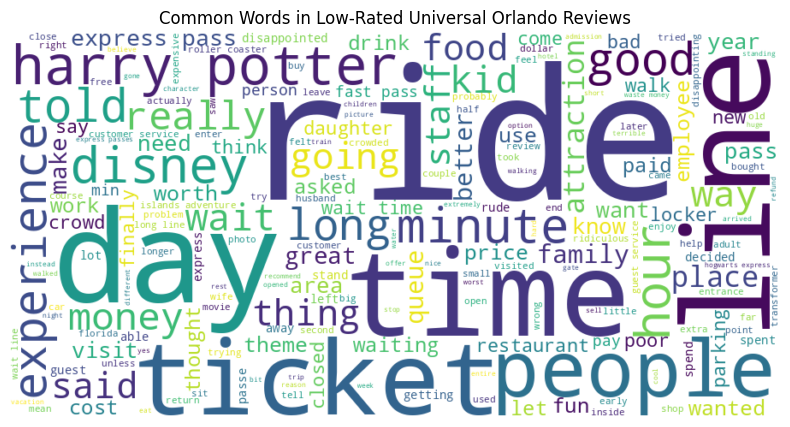

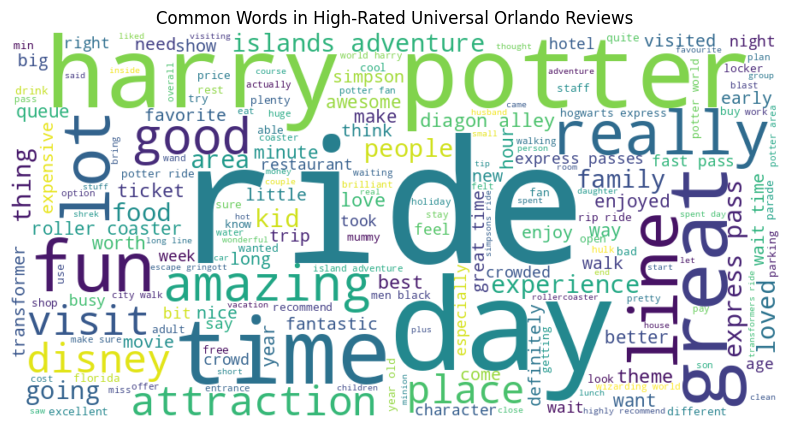

In [10]:
low_text = " ".join(
    comparison.loc[
        comparison["rating_group"] == "Low (1–2)",
        "clean_text"
    ]
)
high_text = " ".join(
    comparison.loc[
        comparison["rating_group"] == "High (4–5)",
        "clean_text"
    ]
)

low_cloud = WordCloud(
    width=900,
    height=450,
    background_color="white"
).generate(low_text)

plt.figure(figsize=(10, 5))
plt.imshow(low_cloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in Low-Rated Universal Orlando Reviews")
plt.show()

high_cloud = WordCloud(
    width=900,
    height=450,
    background_color="white"
).generate(high_text)

plt.figure(figsize=(10, 5))
plt.imshow(high_cloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in High-Rated Universal Orlando Reviews")
plt.show()

**What is one apparent difference between the two word clouds?**

Your answer: The low-rated word cloud features words like "line," "wait," "people," "money," and "tickets," suggesting complaints about crowds, wait times, and cost, while the high-rated word cloud is dominated by more positive or neutral experience words like "fun," "great," "amazing," and "worth," alongside the same core attraction terms.


**What is one limitation of using word clouds for this comparison?**

Your answer: Word clouds only convey relative word size, not exact frequency, so it's hard to tell precisely how much more common one word is than another, or to make a fair numeric comparison between the two groups (especially since the groups are very different sizes).


**After viewing the word clouds, recommend one additional stopword to make the comparison more informative. Explain your choice.**

Your answer: I would add "day" as an additional stopword. It appears prominently in both the low- and high-rated word clouds and bar charts, but it's a generic word almost any visitor would use to describe a day at the park, regardless of whether their experience was positive or negative, so it doesn't help distinguish the two groups.


## 10. Create word-frequency bar charts

Run the provided code. `frequency_frame()` counts every token in a selected rating group, keeps the 15 most frequent words, and sorts them from most to least frequent. With a horizontal Seaborn bar chart, this ordering places the most frequent word at the top.

The code creates separate figures for the Low and High rating groups. The tables are used to construct the figures but are not printed.

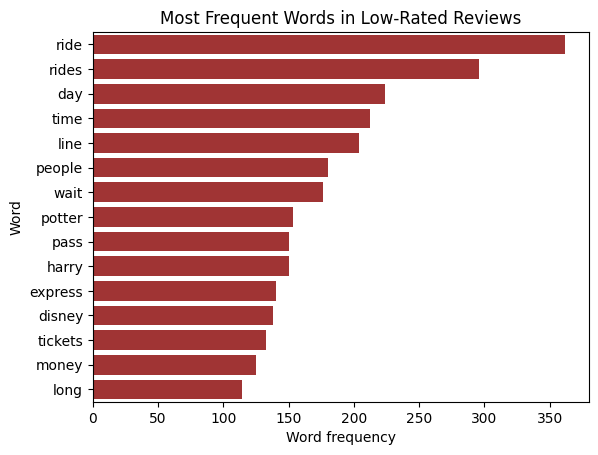

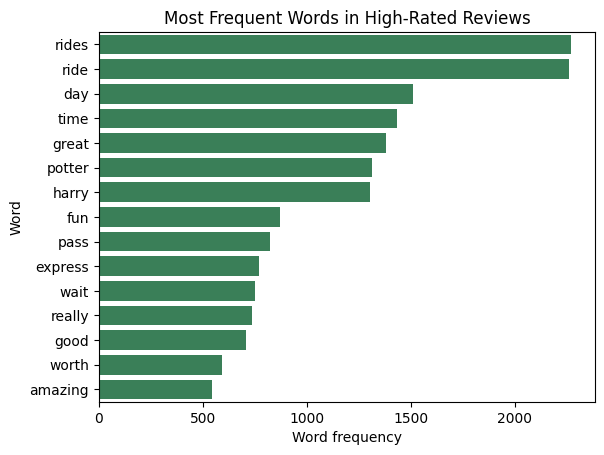

In [11]:
def frequency_frame(group, number_of_words=15):
    counts = Counter(
        word
        for tokens in comparison.loc[
            comparison["rating_group"] == group,
            "tokens"
        ]
        for word in tokens
    )
    return (
        pd.DataFrame(
            counts.most_common(number_of_words),
            columns=["word", "frequency"]
        )
        .sort_values("frequency", ascending=False)
    )


low_frequency = frequency_frame("Low (1–2)")
high_frequency = frequency_frame("High (4–5)")

sns.barplot(
    data=low_frequency,
    x="frequency",
    y="word",
    color="firebrick"
)
plt.title("Most Frequent Words in Low-Rated Reviews")
plt.xlabel("Word frequency")
plt.ylabel("Word")
plt.show()

sns.barplot(
    data=high_frequency,
    x="frequency",
    y="word",
    color="seagreen"
)
plt.title("Most Frequent Words in High-Rated Reviews")
plt.xlabel("Word frequency")
plt.ylabel("Word")
plt.show()

**What do the bar charts make easier to compare than the word clouds?**

Your answer: The bar charts show exact frequency counts on a shared numeric scale, making it possible to precisely rank words within a group and see by how much one word's frequency exceeds another's, rather than relying on the rougher visual size comparison a word cloud provides.


**Which repeated words appear prominently in both groups?**

Your answer: "Rides," "ride," "day," "time," "potter," "harry," "express," "wait," and "pass" all appear prominently in both the low- and high-rated word frequency charts, showing that visitors of both groups discuss the same core attractions (like the Harry Potter areas and Express Pass) and general park experience.


## 11. Compare review lengths

Use `sns.boxplot()` to compare `review_length_words` across the Low and High rating groups. Use `order=["Low (1–2)", "High (4–5)"]`, choose a human-readable color, and add a descriptive title and axis labels.

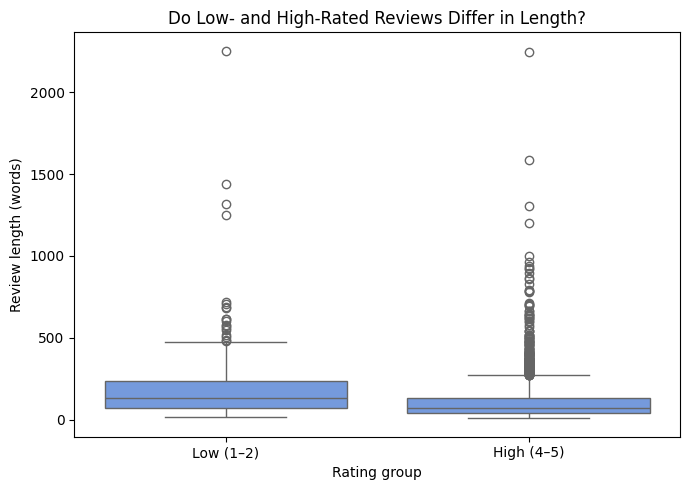

In [12]:
plt.figure(figsize=(7, 5))
ax = sns.boxplot(
    data=comparison,
    x="rating_group",
    y="review_length_words",
    order=["Low (1–2)", "High (4–5)"],
    color="cornflowerblue"
)
ax.set_title("Do Low- and High-Rated Reviews Differ in Length?")
ax.set_xlabel("Rating group")
ax.set_ylabel("Review length (words)")
plt.tight_layout()
plt.show()


**How do the centers and variability of review length compare between the groups?**

Your answer: Low-rated reviews have a noticeably higher median and mean review length (mean about 196 words) than high-rated reviews (mean about 112 words), and they are also more variable, with a much wider interquartile range and higher-reaching outliers. This supports my earlier prediction that dissatisfied visitors tend to write longer reviews.


# Step 6: Conclusion and limitation

**Write a concise conclusion that answers the research question using evidence from the word-frequency and review-length figures.**

Your answer: Low- and high-rated Universal Studios Florida reviews both center on the same core attractions (rides, the Harry Potter areas, and the Express Pass), but they diverge in tone and focus: low-rated reviews emphasize wait times, crowds, and cost ("line," "wait," "people," "money," "tickets"), while high-rated reviews emphasize enjoyment and value ("fun," "great," "amazing," "worth"). Low-rated reviews are also considerably longer on average (about 196 words) than high-rated reviews (about 112 words), suggesting dissatisfied visitors tend to write more detailed explanations of their experience.


**Why do frequent words not necessarily identify the most important causes of a visitor's rating?**

Your answer: A word's frequency only reflects how often it was mentioned, not how much it actually influenced a visitor's rating. A word could appear often simply because it names something nearly every visitor experiences (like "rides" or "day"), while a less frequent but more emotionally significant word (like a specific complaint about safety or a broken ride) could matter far more to that visitor's rating despite appearing rarely in the overall word counts.


**How might the historical time span limit conclusions about current Universal Studios Florida experiences?**

Your answer: The reviews span from February 2004 through May 2021, a period during which the park added and removed attractions (including major additions like the Wizarding World of Harry Potter), changed pricing and pass systems, and operated under different conditions (including pandemic-era changes near the end of the period). Patterns found across this entire historical span may not reflect what visitors experience at the park today, so conclusions from this dataset should not be treated as describing current conditions.


## AI-use reflection

**State whether you used an AI tool and, if you did, identify one suggestion you checked and explain what you accepted, modified, or rejected.**

Your answer: No AI was used for this assignment.

## Submission checklist

- Run every code cell from top to bottom.
- Use all requested DataFrame and feature names.
- Complete every written-response cell.
- Give each figure a readable title and axis labels when axes are present.
- Support the conclusion with evidence from the figures and calculated values.
- Explain relevant limitations of the text and sample.
- Keep the notebook organized and readable.
- Submit the completed notebook by the deadline.